# NB03D — Validación de speckle óptico 2D hasta $z=10\lambda$

Este notebook extiende NB03C desde $5\lambda$ hasta $10\lambda$ sin modificar
NB01, NB02, NB02B, NB03, NB03B ni NB03C. Se mantiene la ecuación completa de
Helmholtz en coordenadas cartesianas $(x,z)$, la representación modal
PINN-SIREN y las condiciones de Cauchy duras.

El tramo ya validado $0\leq z\leq5\lambda$ se reutiliza. Para
$5\lambda<z\leq10\lambda$ se añaden cinco PINN-SIREN locales. El espectro
angular no aporta etiquetas de entrenamiento ni selecciona los pesos: se usa
únicamente después del entrenamiento como referencia independiente.

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in (HERE, *HERE.parents):
    marker = candidate / 'results' / 'nb03_distance_pilot' / 'nb03d_z10_validation' / 'validation_summary.json'
    if marker.exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('No se encontró la raíz del proyecto ni el resumen NB03D.')

SUMMARY_PATH = PROJECT_ROOT / 'results' / 'nb03_distance_pilot' / 'nb03d_z10_validation' / 'validation_summary.json'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
rows = summary['per_screen']
print('Estructura del proyecto localizada correctamente.')
print(f"Resumen: {SUMMARY_PATH.relative_to(PROJECT_ROOT)}")

Estructura del proyecto localizada correctamente.
Resumen: results\nb03_distance_pilot\nb03d_z10_validation\validation_summary.json


## 1. Problema físico normalizado

El campo complejo satisface

$$
\frac{\partial^2 E}{\partial \tilde x^2}+
\frac{\partial^2 E}{\partial \tilde z^2}+\tilde k^2E=0,
\qquad \tilde k=2\pi,
$$

con $\tilde x=x/\lambda$ y $\tilde z=z/\lambda$. El dominio es

$$
\tilde x\in[-10,10),\qquad \tilde z\in[0,10].
$$

Llegar a $\tilde z=10$ significa propagar diez longitudes de onda. El modelo
sigue siendo bidimensional y cartesiano: una coordenada transversal $x$ y una
coordenada longitudinal de propagación $z$.

## 2. Diez PINN-SIREN locales

El campo propagante se descompone en 41 modos:

$$
E(\tilde x,\tilde z)=\sum_m a_m(\tilde z)e^{i\tilde k_{x,m}\tilde x},
\qquad a_m''+\tilde k_{z,m}^2a_m=0.
$$

En el bloque $j$, con coordenada local $\xi=\tilde z-j\in[0,1]$,

$$
a_m^{(j)}(\xi)=A_m^{(j)}+\xi B_m^{(j)}+
\xi^2N_{\theta_j,m}(\xi).
$$

Las interfaces transfieren exactamente valor y derivada:

$$
A_m^{(j)}=a_m^{(j-1)}(1),\qquad
B_m^{(j)}={a_m^{(j-1)}}'(1).
$$

Por tanto, la cadena es continua en campo y derivada por construcción. Cada
bloque conserva cuatro capas ocultas de 128 neuronas y una escala sinusoidal
adaptativa. Dos pantallas (321 y 2026) necesitaron una segunda optimización de
los bloques 5–9; los bloques previos no fueron reentrenados.

## 3. Criterios de aceptación

Cada pantalla debe cumplir simultáneamente:

- $L^2$ complejo final menor que 5 %;
- máximo $L^2$ propagante menor que 5 % en 201 planos;
- coherencia compleja mayor que 0.99;
- correlación de intensidad mayor que 0.99;
- diferencia absoluta de contraste menor que 0.05;
- saltos de campo y derivada menores que $10^{-6}$.

El contraste de una realización finita no tiene que ser exactamente uno. La
comparación correcta aquí es entre el contraste PINN y el de la referencia
para la misma pantalla y distancia.

In [2]:
header = ('pantalla', 'L2 final (%)', 'máx. L2 (%)', 'z máximo', 'coherencia', 'corr. I', '|ΔC|', 'refinada', 'aceptada')
print(f"{header[0]:>8} {header[1]:>13} {header[2]:>13} {header[3]:>10} {header[4]:>12} {header[5]:>10} {header[6]:>10} {header[7]:>10} {header[8]:>10}")
for row in rows:
    print(
        f"{row['screen_seed']:>8d} "
        f"{100*row['l2_full_final']:>13.4f} "
        f"{100*row['l2_propagating_max']:>13.4f} "
        f"{row['l2_propagating_max_z']:>10.2f} "
        f"{row['coherence_full_final']:>12.6f} "
        f"{row['intensity_correlation_full_final']:>10.6f} "
        f"{row['contrast_difference']:>10.6f} "
        f"{str(row['refinement_used']):>10} "
        f"{str(row['accepted']):>10}"
    )

pantalla  L2 final (%)   máx. L2 (%)   z máximo   coherencia    corr. I       |ΔC|   refinada   aceptada
      42        3.2878        3.7265       6.40     0.999475   0.999302   0.001477      False       True
     123        2.7791        3.4833       9.70     0.999704   0.999631   0.002798      False       True
     321        2.3116        2.3931       9.45     0.999849   0.999711   0.009587       True       True
     777        2.7522        3.6193       9.75     0.999632   0.999157   0.004487      False       True
    2026        1.9558        1.9678       9.15     0.999917   0.999572   0.000309       True       True


In [3]:
aggregate = summary['aggregate']
print('RESULTADO AGREGADO — NB03D EN z=10 lambda')
print('-' * 66)
print(f"L2 completo final medio : {100*aggregate['l2_full_final']['mean']:.4f}%")
print(f"Peor L2 completo final  : {100*aggregate['l2_full_final']['maximum']:.4f}%")
print(f"Peor máximo sobre z     : {100*aggregate['l2_propagating_max']['maximum']:.4f}%")
print(f"Coherencia media        : {aggregate['coherence_full_final']['mean']:.6f}")
print(f"Correlación I media     : {aggregate['intensity_correlation_full_final']['mean']:.6f}")
print(f"Diferencia C media      : {aggregate['contrast_difference']['mean']:.6f}")
print(f"Pantallas refinadas     : {aggregate['refined_screens']}/{aggregate['total_screens']}")
print(f"Pantallas aceptadas     : {aggregate['accepted_screens']}/{aggregate['total_screens']}")

RESULTADO AGREGADO — NB03D EN z=10 lambda
------------------------------------------------------------------
L2 completo final medio : 2.6173%
Peor L2 completo final  : 3.2878%
Peor máximo sobre z     : 3.7265%
Coherencia media        : 0.999716
Correlación I media     : 0.999475
Diferencia C media      : 0.003731
Pantallas refinadas     : 2/5
Pantallas aceptadas     : 5/5


## 4. Error a lo largo de los diez bloques

La validación no se limita al plano final. Se compara la predicción contra el
espectro angular en 201 planos; las líneas verticales indican las nueve
interfaces internas.

<>:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\rober\AppData\Local\Temp\ipykernel_24684\1790075449.py:9: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  title='NB03D: error en 201 planos hasta $10\lambda$')


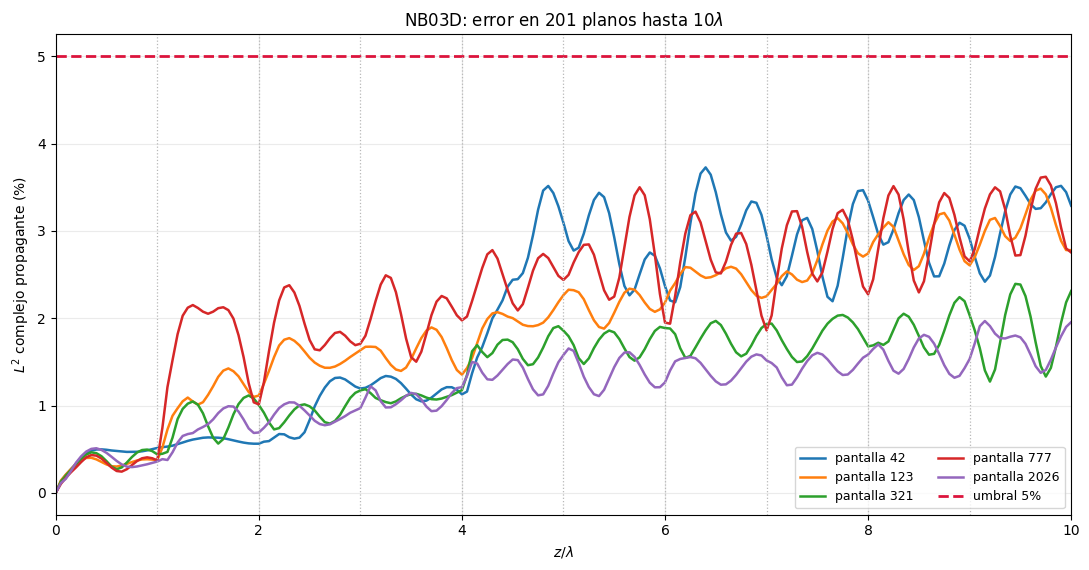

Figura guardada: results\figures\nb03d_z10_l2_multiscreen.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 5.8))
for row in rows:
    data = np.load(PROJECT_ROOT / row['arrays_path'])
    ax.plot(data['z_lambda'], 100*data['l2_propagating'], lw=1.8, label=f"pantalla {row['screen_seed']}")
ax.axhline(5, color='crimson', ls='--', lw=2, label='umbral 5%')
for boundary in range(1, 10):
    ax.axvline(boundary, color='0.72', ls=':', lw=.9)
ax.set(xlabel=r'$z/\lambda$', ylabel=r'$L^2$ complejo propagante (%)',
       title='NB03D: error en 201 planos hasta $10\lambda$')
ax.set_xlim(0, 10)
ax.grid(alpha=.25)
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
path_l2 = FIGURES_DIR / 'nb03d_z10_l2_multiscreen.png'
fig.savefig(path_l2, dpi=180, bbox_inches='tight')
plt.show()
print(f"Figura guardada: {path_l2.relative_to(PROJECT_ROOT)}")

## 5. Evolución espacial representativa

La pantalla 42 permite comparar la intensidad de referencia, la intensidad
PINN-SIREN y el error complejo normalizado durante toda la propagación.

<>:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\rober\AppData\Local\Temp\ipykernel_24684\1768218137.py:27: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  fig.suptitle('Propagación de speckle hasta $10\lambda$ — pantalla 42', y=1.02)


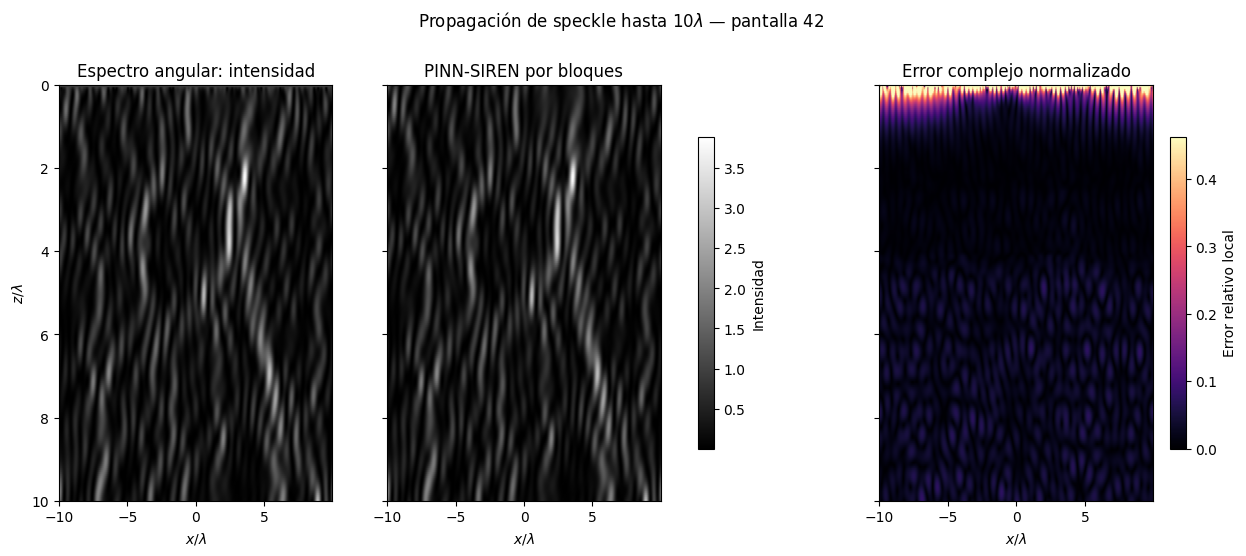

Figura guardada: results\figures\nb03d_z10_propagation_screen42.png


In [5]:
row42 = next(row for row in rows if row['screen_seed'] == 42)
data42 = np.load(PROJECT_ROOT / row42['arrays_path'])
reference42 = np.load(PROJECT_ROOT / 'results' / 'nb03_angular_spectrum_reference_z1_corr0.10.npz')
x = reference42['x_lambda']
z = data42['z_lambda']
field_ref = data42['field_full']
field_pred = data42['field_pred']
intensity_ref = np.abs(field_ref)**2
intensity_pred = np.abs(field_pred)**2
rms = np.sqrt(np.mean(np.abs(field_ref)**2, axis=1, keepdims=True))
error = np.abs(field_pred-field_ref) / np.maximum(rms, 1e-12)
extent = [x.min(), x.max(), z.max(), z.min()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.4), sharey=True)
im0 = axes[0].imshow(intensity_ref, aspect='auto', extent=extent, cmap='gray')
axes[0].set_title('Espectro angular: intensidad')
axes[1].imshow(intensity_pred, aspect='auto', extent=extent, cmap='gray')
axes[1].set_title('PINN-SIREN por bloques')
im2 = axes[2].imshow(error, aspect='auto', extent=extent, cmap='magma', vmin=0,
                     vmax=np.percentile(error, 99))
axes[2].set_title('Error complejo normalizado')
for ax in axes:
    ax.set_xlabel(r'$x/\lambda$')
axes[0].set_ylabel(r'$z/\lambda$')
fig.colorbar(im0, ax=axes[:2], shrink=.75, label='Intensidad')
fig.colorbar(im2, ax=axes[2], shrink=.75, label='Error relativo local')
fig.suptitle('Propagación de speckle hasta $10\lambda$ — pantalla 42', y=1.02)
path_map = FIGURES_DIR / 'nb03d_z10_propagation_screen42.png'
fig.savefig(path_map, dpi=180, bbox_inches='tight')
plt.show()
print(f"Figura guardada: {path_map.relative_to(PROJECT_ROOT)}")

## 6. Plano final en $z=10\lambda$

<>:14: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:14: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\rober\AppData\Local\Temp\ipykernel_24684\19203245.py:14: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  fig.suptitle('Plano final en $z=10\lambda$ — pantalla 42')


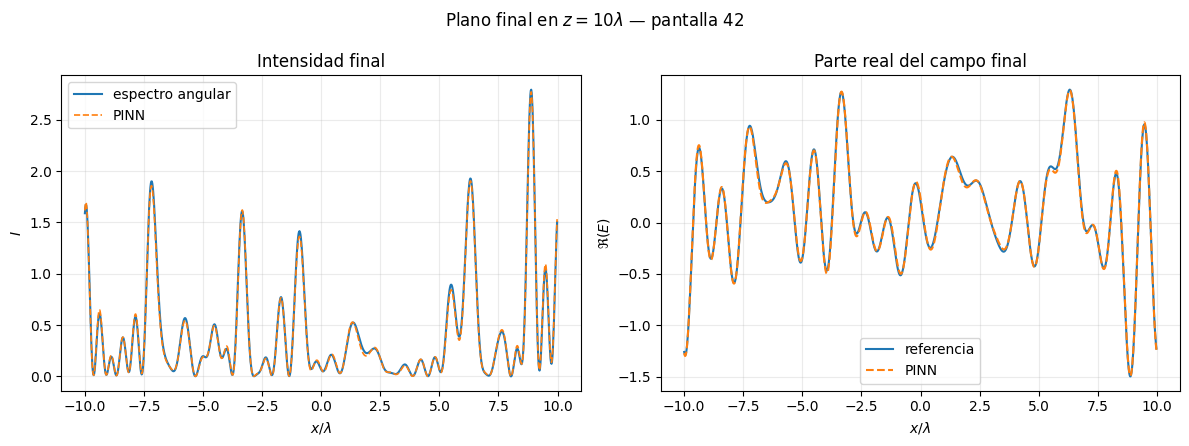

Figura guardada: results\figures\nb03d_z10_final_screen42.png


In [6]:
iref = intensity_ref[-1]
ipred = intensity_pred[-1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(x, iref, label='espectro angular', lw=1.5)
axes[0].plot(x, ipred, '--', label='PINN', lw=1.2)
axes[0].set(title='Intensidad final', xlabel=r'$x/\lambda$', ylabel='$I$')
axes[0].legend()
axes[1].plot(x, field_ref[-1].real, label='referencia')
axes[1].plot(x, field_pred[-1].real, '--', label='PINN')
axes[1].set(title='Parte real del campo final', xlabel=r'$x/\lambda$', ylabel=r'$\Re(E)$')
axes[1].legend()
for ax in axes:
    ax.grid(alpha=.25)
fig.suptitle('Plano final en $z=10\lambda$ — pantalla 42')
fig.tight_layout()
path_final = FIGURES_DIR / 'nb03d_z10_final_screen42.png'
fig.savefig(path_final, dpi=180, bbox_inches='tight')
plt.show()
print(f"Figura guardada: {path_final.relative_to(PROJECT_ROOT)}")

## 7. Continuidad en las interfaces

La condición de Cauchy dura debe conservar simultáneamente el campo y su
derivada longitudinal en las nueve interfaces.

In [7]:
for row in rows:
    print(
        f"pantalla {row['screen_seed']:>4}: "
        f"salto campo={row['interface_field_max_abs']:.3e}, "
        f"salto derivada={row['interface_derivative_max_abs']:.3e}"
    )

pantalla   42: salto campo=0.000e+00, salto derivada=0.000e+00
pantalla  123: salto campo=0.000e+00, salto derivada=0.000e+00
pantalla  321: salto campo=0.000e+00, salto derivada=0.000e+00
pantalla  777: salto campo=0.000e+00, salto derivada=0.000e+00
pantalla 2026: salto campo=0.000e+00, salto derivada=0.000e+00


## 8. Interpretación y alcance

Las cinco pantallas conocidas cumplen los seis criterios hasta
$10\lambda$. Esto amplía la distancia validada de la metodología por
descomposición de dominio y muestra que el error no tiene que crecer de forma
monótona al añadir bloques, siempre que cada problema local se optimice y la
interfaz se imponga exactamente.

El resultado **no** demuestra que una única PINN global funcione en
$10\lambda$, que la red generalice a pantallas no vistas ni que opere a una
distancia arbitraria. Tampoco demuestra aceleración frente a FEM; esa pregunta
corresponde a NB04.